## 0. Setup and Imports

In [1]:
# =========================================
# ⚙️ Imports & Setup
# =========================================

"""
This section initializes all required libraries.
Keep this clean — no data logic here.
"""

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb

# Time Series
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# =========================================
# 📏 Evaluation Function
# =========================================

"""
This function computes:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

Used for comparing all models consistently.
"""

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(y_true, y_pred, model_name="Model"):
    """
    Evaluate model performance using MAE, RMSE, and MAPE.
    """

    # Convert to numpy arrays (safe handling)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Avoid division by zero in MAPE
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    # Print nicely
    print(f"\n===== {model_name} Performance =====")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAPE : {mape:.2f}%")

    return mae, rmse, mape

## 1. Load Processed Data

In [3]:
# =========================================
# 📂 Load Feature-Engineered Data
# =========================================

"""
We load already processed datasets.
No preprocessing should be done here.
"""

from pathlib import Path

# Update this path if needed
BASE_PATH = Path(r"C:\Users\Shriyans S Sahoo\IIIT Dharwad\Academics\Sem 4\Time Series Forecasting\TimeSeries Project")

DATA_PATH = BASE_PATH / "data" / "processed"

# Load datasets
daily_df = pd.read_csv(DATA_PATH / "daily_features.csv", parse_dates=["date"])
timeseries_df = pd.read_csv(DATA_PATH / "timeseries_features.csv", parse_dates=["datetime"])

print("Daily shape:", daily_df.shape)
print("TimeSeries shape:", timeseries_df.shape)

Daily shape: (1048, 18)
TimeSeries shape: (33307, 14)


In [4]:
# Quick sanity check
print("\nDaily columns:\n", daily_df.columns.tolist())
print("\nTimeseries columns:\n", timeseries_df.columns.tolist())

print("\nDaily head:")
display(daily_df.head())

print("\nTimeseries head:")
display(timeseries_df.head())


Daily columns:
 ['date', 'max_demand_met_mw', 'day_of_week', 'month', 'is_weekend', 'is_festival', 'is_pre', 'is_post', 'festival_name', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_std_7']

Timeseries columns:
 ['datetime', 'demand_met_mw', 'date', 'hour', 'minute', 'day_of_week', 'time_block', 'hour_sin', 'hour_cos', 'lag_1', 'lag_96', 'is_festival', 'is_pre', 'is_post']

Daily head:


,date,max_demand_met_mw,day_of_week,month,is_weekend,is_festival,is_pre,is_post,festival_name,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7
0,2023-05-01,159720.0,0,5,0,1,0,0,none,0.000000,1.000000,0.5,-0.866025,173339.0,191917.0,180284.0,186469.857143,14431.224797
1,2023-05-02,173208.0,1,5,0,0,0,1,Labour Day,0.781831,0.623490,0.5,-0.866025,159720.0,194367.0,174691.0,183447.142857,14714.595208
2,2023-05-03,172050.0,2,5,0,0,0,1,Labour Day,0.974928,-0.222521,0.5,-0.866025,173208.0,195821.0,187729.0,180051.285714,14113.678220
3,2023-05-04,178915.0,3,5,0,0,1,0,Buddha Purnima,0.433884,-0.900969,0.5,-0.866025,172050.0,196240.0,189684.0,177576.285714,12189.563688
4,2023-05-05,184356.0,4,5,0,1,0,0,none,-0.433884,-0.900969,0.5,-0.866025,178915.0,197000.0,189003.0,175770.000000,9463.596480



Timeseries head:


,datetime,demand_met_mw,date,hour,minute,day_of_week,time_block,hour_sin,hour_cos,lag_1,lag_96,is_festival,is_pre,is_post
0,2025-04-02 00:00:00,191210.0,2025-04-02,0,0,2,0,0.000000,1.000000,192857.0,191368.0,0,0,1
1,2025-04-02 00:15:00,191978.0,2025-04-02,0,15,2,1,0.000000,1.000000,191210.0,190921.0,0,0,1
2,2025-04-02 00:30:00,190861.0,2025-04-02,0,30,2,2,0.000000,1.000000,191978.0,190222.0,0,0,1
3,2025-04-02 00:45:00,190175.0,2025-04-02,0,45,2,3,0.000000,1.000000,190861.0,188971.0,0,0,1
4,2025-04-02 01:00:00,187833.0,2025-04-02,1,0,2,4,0.258819,0.965926,190175.0,188162.0,0,0,1


## 2. Train-Test Split

In [5]:
# =========================================
# 📌 SECTION 2 — Train / Val / Test Split
# =========================================

"""
We split the data chronologically (NOT randomly) to avoid data leakage.

Split strategy:
- Train: 70%
- Validation: 15%
- Test: 15%

This is done separately for:
1. Daily dataset (3 years data)
2. TimeSeries dataset (1 year, 15-min data)
"""

# -------------------------------
# 🔹 DAILY DATA SPLIT
# -------------------------------

# Ensure sorted by date
daily_df = daily_df.sort_values("date").reset_index(drop=True)

# Compute split indices
n = len(daily_df)

train_end = int(0.7 * n)
val_end = int(0.85 * n)

# Split
train_daily = daily_df.iloc[:train_end]
val_daily   = daily_df.iloc[train_end:val_end]
test_daily  = daily_df.iloc[val_end:]

# Print summary
print("===== DAILY DATA SPLIT =====")
print(f"Train range: {train_daily['date'].min()} → {train_daily['date'].max()}")
print(f"Val range:   {val_daily['date'].min()} → {val_daily['date'].max()}")
print(f"Test range:  {test_daily['date'].min()} → {test_daily['date'].max()}")

print(f"Train size: {len(train_daily)}")
print(f"Val size:   {len(val_daily)}")
print(f"Test size:  {len(test_daily)}")


# -------------------------------
# 🔹 TIMESERIES DATA SPLIT
# -------------------------------

# Ensure sorted by datetime
timeseries_df = timeseries_df.sort_values("datetime").reset_index(drop=True)

# Compute split indices
n_ts = len(timeseries_df)

train_end_ts = int(0.7 * n_ts)
val_end_ts   = int(0.85 * n_ts)

# Split
train_ts = timeseries_df.iloc[:train_end_ts]
val_ts   = timeseries_df.iloc[train_end_ts:val_end_ts]
test_ts  = timeseries_df.iloc[val_end_ts:]

# Print summary
print("\n===== TIMESERIES DATA SPLIT =====")
print(f"Train range: {train_ts['datetime'].min()} → {train_ts['datetime'].max()}")
print(f"Val range:   {val_ts['datetime'].min()} → {val_ts['datetime'].max()}")
print(f"Test range:  {test_ts['datetime'].min()} → {test_ts['datetime'].max()}")

print(f"Train size: {len(train_ts)}")
print(f"Val size:   {len(val_ts)}")
print(f"Test size:  {len(test_ts)}")

===== DAILY DATA SPLIT =====
Train range: 2023-05-01 00:00:00 → 2025-05-04 00:00:00
Val range:   2025-05-05 00:00:00 → 2025-10-23 00:00:00
Test range:  2025-10-24 00:00:00 → 2026-03-31 00:00:00
Train size: 733
Val size:   157
Test size:  158

===== TIMESERIES DATA SPLIT =====
Train range: 2025-04-02 00:00:00 → 2025-12-17 21:15:00
Val range:   2025-12-17 21:30:00 → 2026-02-07 22:15:00
Test range:  2026-02-07 22:30:00 → 2026-03-31 23:45:00
Train size: 23314
Val size:   4996
Test size:  4997


# DAILY FORECASTING

## 3. Baseline Models (Daily Forecasting)


===== Mean Model (Daily) Performance =====
MAE  : 17836.17
RMSE : 19871.51
MAPE : 7.94%


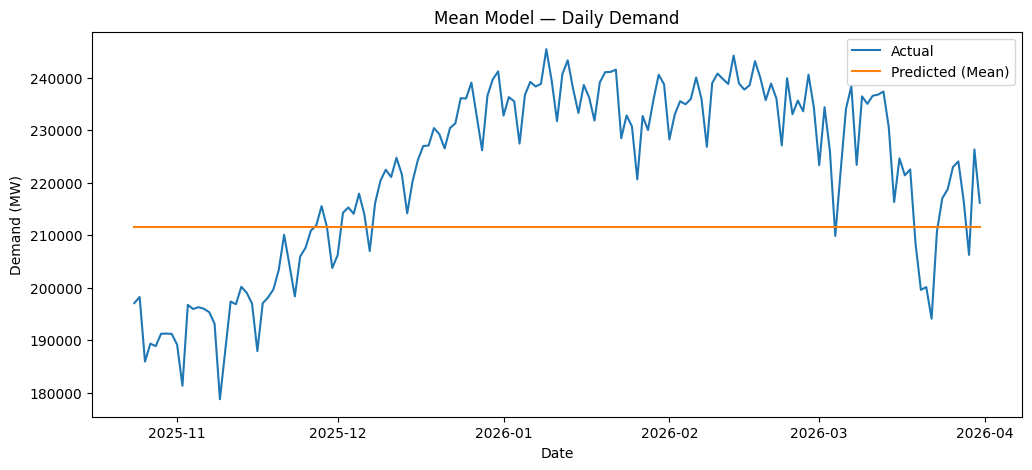

In [6]:
# =========================================
# 📊 Mean Model (Daily)
# =========================================

"""
Prediction = Mean of training data
Very basic baseline
"""

import matplotlib.pyplot as plt

# Compute mean from training set
mean_value = train_daily["max_demand_met_mw"].mean()

# Predict constant value
y_pred = [mean_value] * len(test_daily)

# Actual values
y_true = test_daily["max_demand_met_mw"]

# Evaluate
evaluate_model(y_true, y_pred, model_name="Mean Model (Daily)")

# Plot
plt.figure(figsize=(12,5))
plt.plot(test_daily["date"], y_true, label="Actual")
plt.plot(test_daily["date"], y_pred, label="Predicted (Mean)")
plt.title("Mean Model — Daily Demand")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.show()


===== Naive Model (Daily) Performance =====
MAE  : 5173.80
RMSE : 6756.05
MAPE : 2.36%


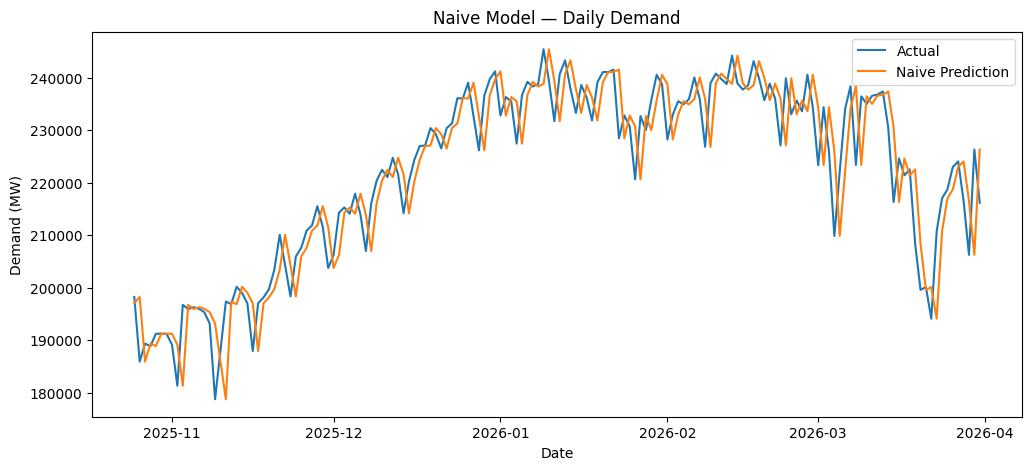

In [7]:
# =========================================
# 📊 Naive Model (Daily)
# =========================================

"""
Prediction = Previous day's demand
y(t) = y(t-1)
"""

# Shift by 1
test_naive = test_daily.copy()
test_naive["pred"] = test_naive["max_demand_met_mw"].shift(1)

# Drop first NaN
test_naive = test_naive.dropna()

y_true = test_naive["max_demand_met_mw"]
y_pred = test_naive["pred"]

# Evaluate
evaluate_model(y_true, y_pred, model_name="Naive Model (Daily)")

# Plot
plt.figure(figsize=(12,5))
plt.plot(test_naive["date"], y_true, label="Actual")
plt.plot(test_naive["date"], y_pred, label="Naive Prediction")
plt.title("Naive Model — Daily Demand")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.show()


===== Seasonal Naive (Daily) Performance =====
MAE  : 6801.68
RMSE : 9204.84
MAPE : 3.10%


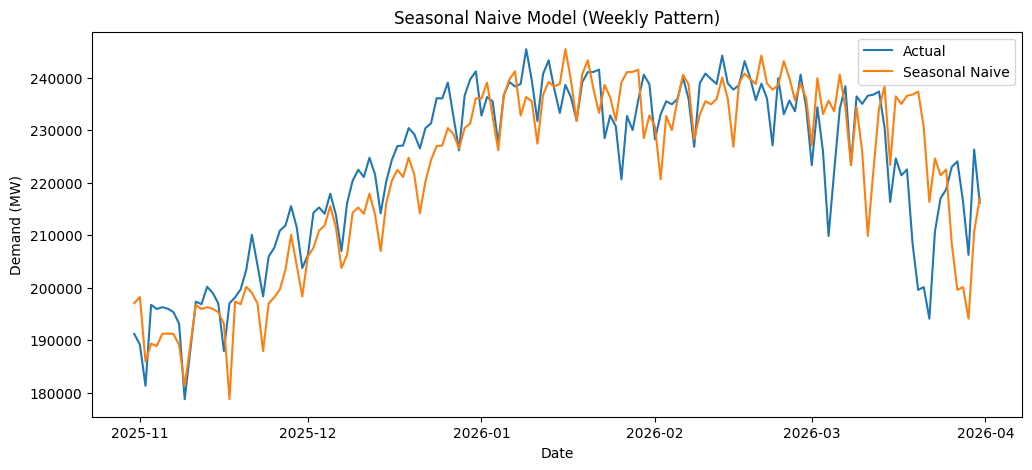

In [8]:
# =========================================
# 📊 Seasonal Naive Model (Daily)
# =========================================

"""
Prediction = Same day last week
y(t) = y(t-7)
"""

test_seasonal = test_daily.copy()
test_seasonal["pred"] = test_seasonal["max_demand_met_mw"].shift(7)

test_seasonal = test_seasonal.dropna()

y_true = test_seasonal["max_demand_met_mw"]
y_pred = test_seasonal["pred"]

# Evaluate
evaluate_model(y_true, y_pred, model_name="Seasonal Naive (Daily)")

# Plot
plt.figure(figsize=(12,5))
plt.plot(test_seasonal["date"], y_true, label="Actual")
plt.plot(test_seasonal["date"], y_pred, label="Seasonal Naive")
plt.title("Seasonal Naive Model (Weekly Pattern)")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.show()


===== Drift Model (Daily) Performance =====
MAE  : 18730.97
RMSE : 21345.68
MAPE : 8.20%


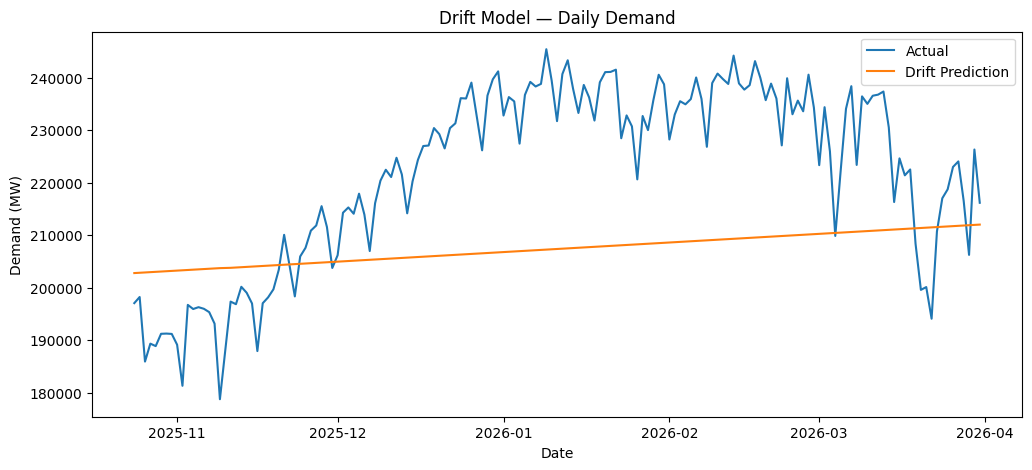

In [9]:
# =========================================
# 📊 Drift Model (Daily)
# =========================================

"""
Linear trend from first to last training point
"""

train = train_daily["max_demand_met_mw"].values
n = len(train)

# Drift formula
drift_preds = []

for i in range(len(test_daily)):
    pred = train[-1] + (i+1) * (train[-1] - train[0]) / (n - 1)
    drift_preds.append(pred)

y_true = test_daily["max_demand_met_mw"]

# Evaluate
evaluate_model(y_true, drift_preds, model_name="Drift Model (Daily)")

# Plot
plt.figure(figsize=(12,5))
plt.plot(test_daily["date"], y_true, label="Actual")
plt.plot(test_daily["date"], drift_preds, label="Drift Prediction")
plt.title("Drift Model — Daily Demand")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.show()


===== SES Model (Daily) Performance =====
MAE  : 21386.33
RMSE : 24165.24
MAPE : 9.36%


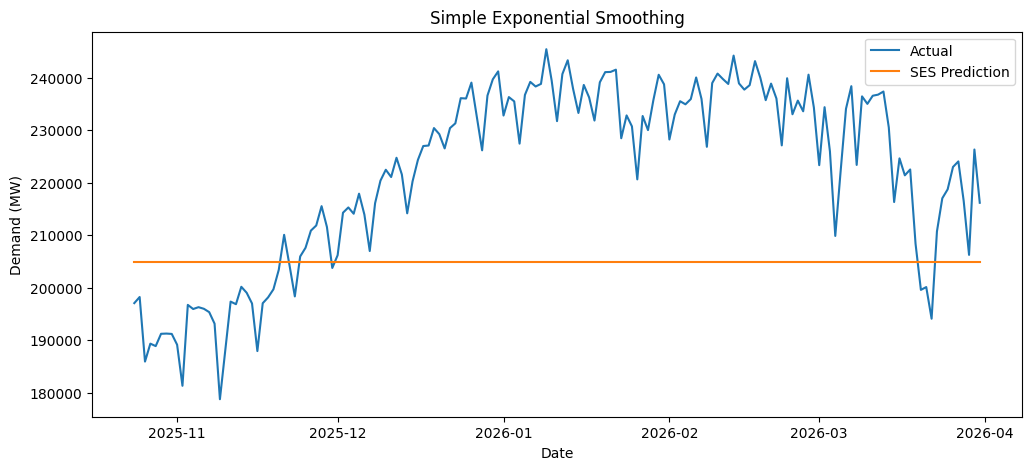

In [10]:
# =========================================
# 📊 Simple Exponential Smoothing (Daily)
# =========================================

from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Train model
ses_model = SimpleExpSmoothing(train_daily["max_demand_met_mw"]).fit()

# Forecast
y_pred = ses_model.forecast(len(test_daily))
y_true = test_daily["max_demand_met_mw"]

# Evaluate
evaluate_model(y_true, y_pred, model_name="SES Model (Daily)")

# Plot
plt.figure(figsize=(12,5))
plt.plot(test_daily["date"], y_true, label="Actual")
plt.plot(test_daily["date"], y_pred, label="SES Prediction")
plt.title("Simple Exponential Smoothing")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.show()


===== Holt Model (Daily) Performance =====
MAE  : 17612.08
RMSE : 19929.57
MAPE : 7.75%


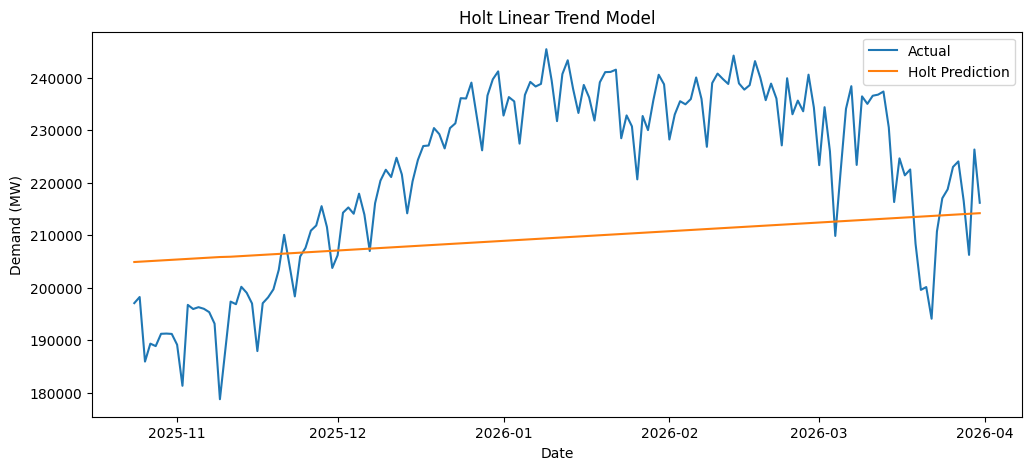

In [11]:
# =========================================
# 📊 Holt Linear Trend (Daily)
# =========================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing

holt_model = ExponentialSmoothing(
    train_daily["max_demand_met_mw"],
    trend="add",
    seasonal=None
).fit()

y_pred = holt_model.forecast(len(test_daily))
y_true = test_daily["max_demand_met_mw"]

# Evaluate
evaluate_model(y_true, y_pred, model_name="Holt Model (Daily)")

# Plot
plt.figure(figsize=(12,5))
plt.plot(test_daily["date"], y_true, label="Actual")
plt.plot(test_daily["date"], y_pred, label="Holt Prediction")
plt.title("Holt Linear Trend Model")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.show()


===== Holt-Winters (Daily) Performance =====
MAE  : 17698.32
RMSE : 19963.78
MAPE : 7.85%


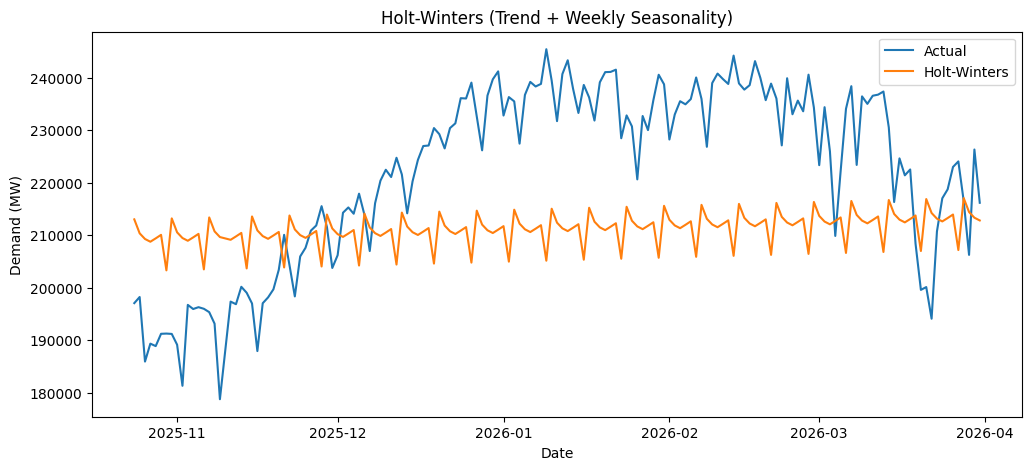

In [12]:
# =========================================
# 📊 Holt-Winters Model (Daily)
# =========================================

"""
Captures:
- Trend
- Weekly seasonality (period = 7)
"""

hw_model = ExponentialSmoothing(
    train_daily["max_demand_met_mw"],
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit()

y_pred = hw_model.forecast(len(test_daily))
y_true = test_daily["max_demand_met_mw"]

# Evaluate
evaluate_model(y_true, y_pred, model_name="Holt-Winters (Daily)")

# Plot
plt.figure(figsize=(12,5))
plt.plot(test_daily["date"], y_true, label="Actual")
plt.plot(test_daily["date"], y_pred, label="Holt-Winters")
plt.title("Holt-Winters (Trend + Weekly Seasonality)")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.show()

#### Among baseline models, the Naive model performed best, indicating strong temporal dependency in the data. 
#### Traditional statistical smoothing models failed to capture volatility and non-linear patterns. 
#### This suggests that more advanced models like ARIMA and machine learning approaches are required.

## 4. ARIMA Models (Daily Forecasting)


===== AR (Daily) Performance =====
MAE  : 4935.64
RMSE : 6187.09
MAPE : 2.24%


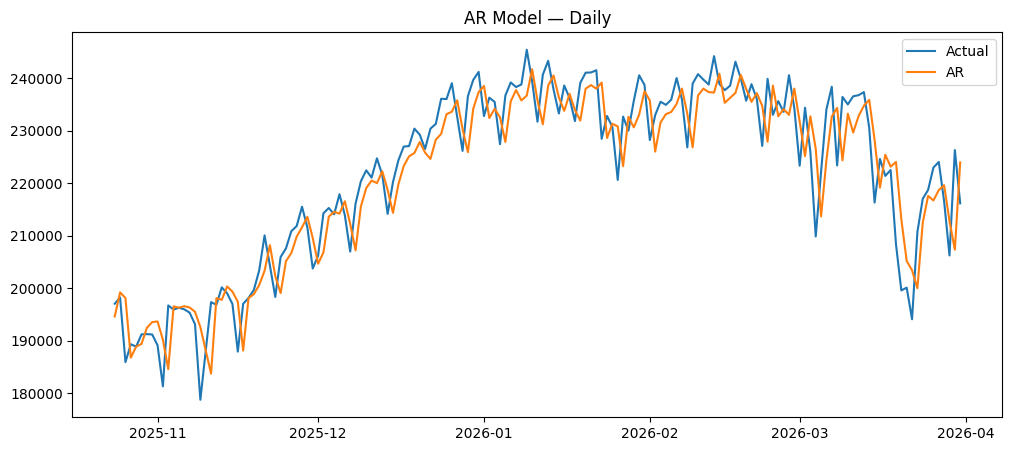

In [13]:
# ============================================
# AR Model (Daily)
# ============================================

from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Combine Train + Val
trainval_daily = pd.concat([train_daily, val_daily]).sort_values("date")

# Drop NA for lags
cols = ["max_demand_met_mw", "lag_1", "lag_7"]
trainval_daily = trainval_daily.dropna(subset=cols)
test_ar = test_daily.dropna(subset=cols).copy()

# Features
X_train = trainval_daily[["lag_1", "lag_7"]]
y_train = trainval_daily["max_demand_met_mw"]

X_test = test_ar[["lag_1", "lag_7"]]
y_test = test_ar["max_demand_met_mw"]

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
evaluate_model(y_test, y_pred, model_name="AR (Daily)")

# Plot
plt.figure(figsize=(12,5))
plt.plot(test_ar["date"], y_test, label="Actual")
plt.plot(test_ar["date"], y_pred, label="AR")
plt.legend()
plt.title("AR Model — Daily")
plt.show()

Training ARIMA model...
Model trained successfully

===== ARIMA (Validation) Performance =====
MAE  : 11808.54
RMSE : 14323.60
MAPE : 5.39%


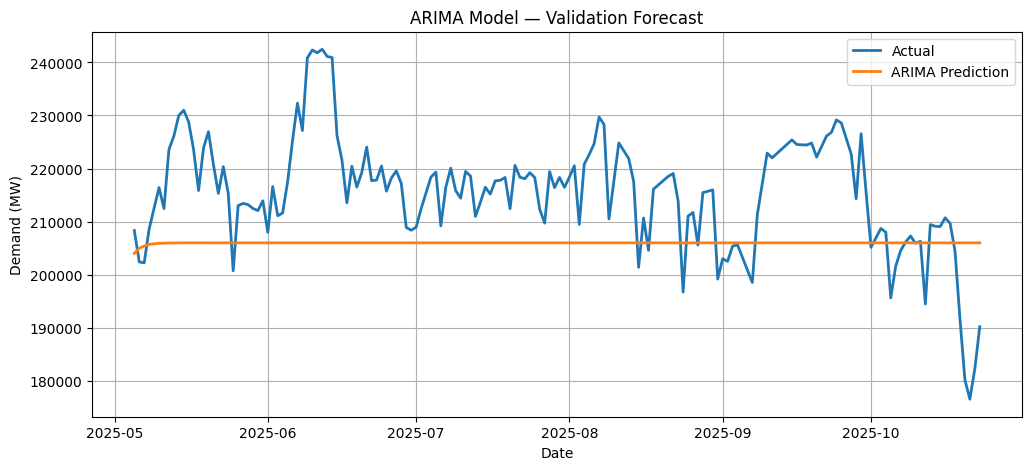

In [14]:
# ============================================
# 📈 ARIMA MODEL (Daily)
# ============================================

"""
ARIMA Model (Daily Demand Forecasting)

We use ARIMA(p,d,q) to capture:
- Autoregression (lag relationships)
- Differencing (to make series stationary)
- Moving average (error smoothing)

Using VALIDATION SET for tuning (not test set)
"""

from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# --------------------------------------------
# Prepare Data
# --------------------------------------------
y_train = train_daily["max_demand_met_mw"]
y_val = val_daily["max_demand_met_mw"]

# --------------------------------------------
# Fit ARIMA model
# (Start with simple configuration)
# --------------------------------------------
print("Training ARIMA model...")

model = ARIMA(y_train, order=(3,1,2))   # (p,d,q)
model_fit = model.fit()

print("Model trained successfully")

# --------------------------------------------
# Forecast on validation set
# --------------------------------------------
val_pred = model_fit.forecast(steps=len(y_val))

# --------------------------------------------
# Evaluate
# --------------------------------------------
evaluate_model(y_val, val_pred, model_name="ARIMA (Validation)")

# --------------------------------------------
# Visualization
# --------------------------------------------
plt.figure(figsize=(12,5))

plt.plot(val_daily["date"], y_val, label="Actual", linewidth=2)
plt.plot(val_daily["date"], val_pred, label="ARIMA Prediction", linewidth=2)

plt.title("ARIMA Model — Validation Forecast")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)

plt.show()

#### The ARIMA model fails to capture variability in the data and collapses to near-constant predictions. This indicates the presence of strong seasonality and external factors, which ARIMA cannot model effectively.

Training corrected SARIMA model...
Model trained successfully

===== SARIMA FIXED (Validation) Performance =====
MAE  : 8132.98
RMSE : 11131.48
MAPE : 3.86%


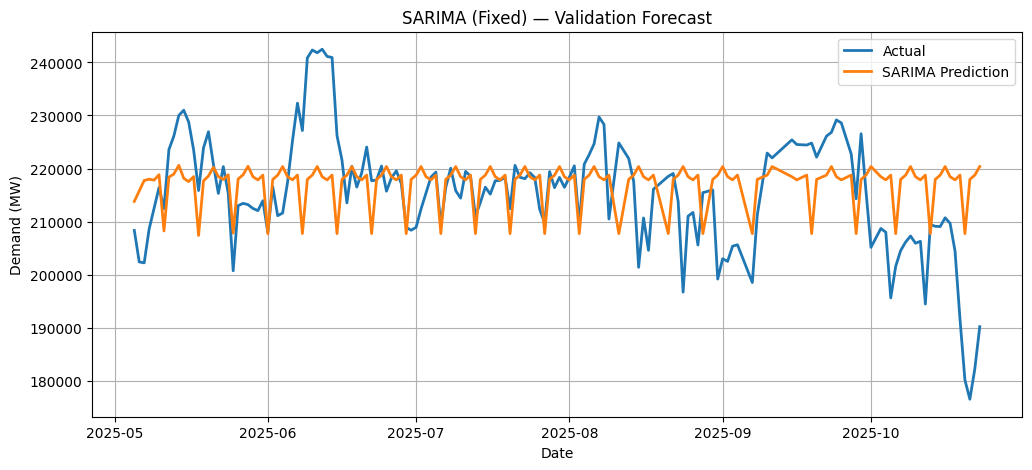

In [15]:
# ============================================
# 📈 SARIMA MODEL (Daily) — FIXED VERSION
# ============================================

"""
Fix:
- Remove regular differencing (d=0)
- Keep seasonal differencing (D=1)

This avoids over-differencing and trend distortion
"""

from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# --------------------------------------------
# Data
# --------------------------------------------
y_train = train_daily["max_demand_met_mw"]
y_val = val_daily["max_demand_met_mw"]

# --------------------------------------------
# Train model
# --------------------------------------------
print("Training corrected SARIMA model...")

model = SARIMAX(
    y_train,
    order=(2,0,2),                 # FIXED
    seasonal_order=(1,1,1,7),      # weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)

print("Model trained successfully")

# --------------------------------------------
# Forecast
# --------------------------------------------
val_pred = model_fit.forecast(steps=len(y_val))

# --------------------------------------------
# Evaluate
# --------------------------------------------
evaluate_model(y_val, val_pred, model_name="SARIMA FIXED (Validation)")

# --------------------------------------------
# Plot
# --------------------------------------------
plt.figure(figsize=(12,5))

plt.plot(val_daily["date"], y_val, label="Actual", linewidth=2)
plt.plot(val_daily["date"], val_pred, label="SARIMA Prediction", linewidth=2)

plt.title("SARIMA (Fixed) — Validation Forecast")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)

plt.show()

#### SARIMA captures seasonality but fails to model short-term fluctuations and external influences, resulting in underperformance compared to the Naive model.

Training SARIMAX model...
Model trained successfully

===== SARIMAX (Validation) Performance =====
MAE  : 8526.01
RMSE : 11485.38
MAPE : 4.03%


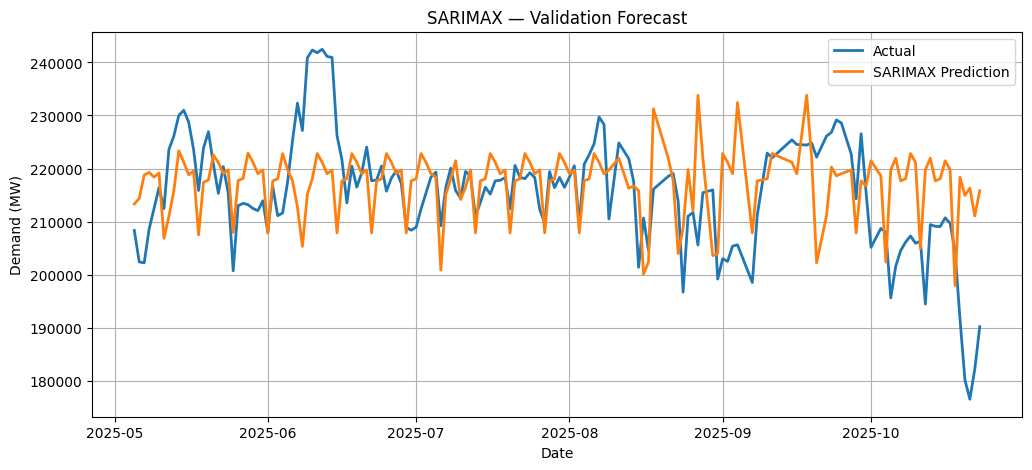

In [16]:
# ============================================
# 📈 SARIMAX MODEL (Daily)
# ============================================

"""
SARIMAX = SARIMA + Exogenous Variables

We now include:
- festival effects
- weekend effects

This should improve performance over SARIMA
"""

from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# --------------------------------------------
# Data
# --------------------------------------------
y_train = train_daily["max_demand_met_mw"]
y_val = val_daily["max_demand_met_mw"]

# Exogenous features
exog_cols = ["is_festival", "is_pre", "is_post", "is_weekend"]

X_train = train_daily[exog_cols]
X_val = val_daily[exog_cols]

# --------------------------------------------
# Train model
# --------------------------------------------
print("Training SARIMAX model...")

model = SARIMAX(
    y_train,
    exog=X_train,
    order=(2,0,2),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)

print("Model trained successfully")

# --------------------------------------------
# Forecast
# --------------------------------------------
val_pred = model_fit.forecast(
    steps=len(y_val),
    exog=X_val
)

# --------------------------------------------
# Evaluate
# --------------------------------------------
evaluate_model(y_val, val_pred, model_name="SARIMAX (Validation)")

# --------------------------------------------
# Plot
# --------------------------------------------
plt.figure(figsize=(12,5))

plt.plot(val_daily["date"], y_val, label="Actual", linewidth=2)
plt.plot(val_daily["date"], val_pred, label="SARIMAX Prediction", linewidth=2)

plt.title("SARIMAX — Validation Forecast")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)

plt.show()

#### Incorporating exogenous variables using SARIMAX did not improve performance, indicating that external features like festivals and weekends have limited predictive power compared to autoregressive components.

## 5. Machine Learning Models (Daily Forecasting)

Training XGBoost model...
Model trained successfully

===== XGBoost (Validation) Performance =====
MAE  : 3947.95
RMSE : 5315.22
MAPE : 1.85%


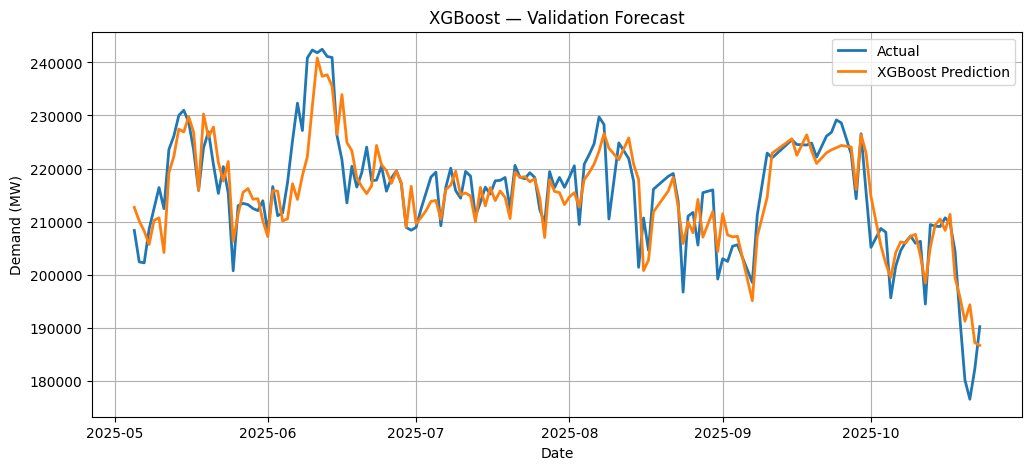

In [17]:
# ============================================
# 🚀 XGBOOST MODEL (Daily)
# ============================================

"""
XGBoost Model

Uses:
- lag features
- rolling stats
- calendar features

This should outperform all previous models
"""

from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# --------------------------------------------
# Features
# --------------------------------------------
feature_cols = [
    "lag_1", "lag_7", "lag_30",
    "rolling_mean_7", "rolling_std_7",
    "day_of_week", "is_weekend",
    "month",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "is_festival", "is_pre", "is_post"
]

# --------------------------------------------
# Data
# --------------------------------------------
X_train = train_daily[feature_cols]
y_train = train_daily["max_demand_met_mw"]

X_val = val_daily[feature_cols]
y_val = val_daily["max_demand_met_mw"]

# --------------------------------------------
# Train model
# --------------------------------------------
print("Training XGBoost model...")

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")

# --------------------------------------------
# Predict
# --------------------------------------------
val_pred = model.predict(X_val)

# --------------------------------------------
# Evaluate
# --------------------------------------------
evaluate_model(y_val, val_pred, model_name="XGBoost (Validation)")

# --------------------------------------------
# Plot
# --------------------------------------------
plt.figure(figsize=(12,5))

plt.plot(val_daily["date"], y_val, label="Actual", linewidth=2)
plt.plot(val_daily["date"], val_pred, label="XGBoost Prediction", linewidth=2)

plt.title("XGBoost — Validation Forecast")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)

plt.show()

#### XGBoost outperforms all statistical models and baseline methods by effectively leveraging lag features, rolling statistics, and calendar-based features. It captures both short-term dependencies and non-linear patterns in the data.

Training Random Forest...
Model trained successfully

===== Random Forest (Validation) Performance =====
MAE  : 3534.06
RMSE : 4982.02
MAPE : 1.65%


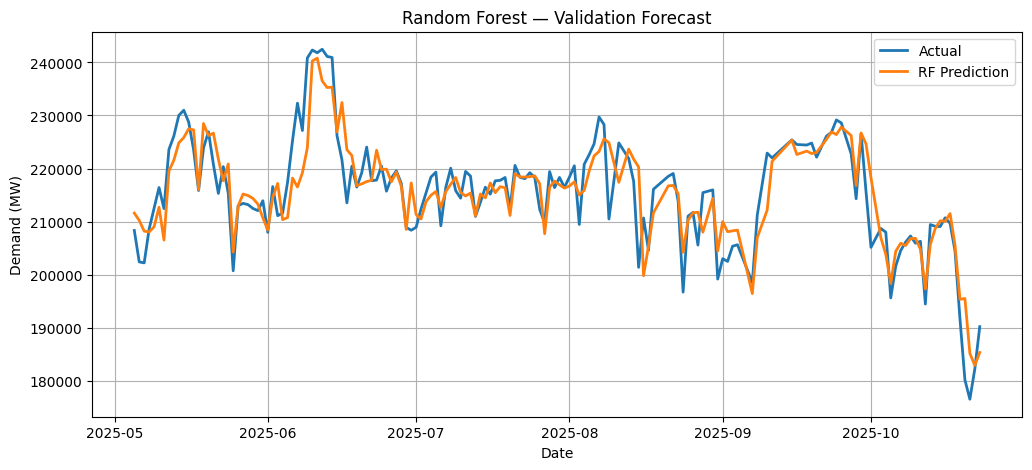

In [18]:
# ============================================
# 🌲 RANDOM FOREST MODEL (Daily)
# ============================================

"""
Random Forest:
- Ensemble of decision trees (bagging)
- Good for nonlinear patterns
- Less prone to overfitting than single trees
"""

from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# --------------------------------------------
# Features
# --------------------------------------------
feature_cols = [
    "lag_1", "lag_7", "lag_30",
    "rolling_mean_7", "rolling_std_7",
    "day_of_week", "is_weekend",
    "month",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "is_festival", "is_pre", "is_post"
]

# --------------------------------------------
# Data
# --------------------------------------------
X_train = train_daily[feature_cols]
y_train = train_daily["max_demand_met_mw"]

X_val = val_daily[feature_cols]
y_val = val_daily["max_demand_met_mw"]

# --------------------------------------------
# Train
# --------------------------------------------
print("Training Random Forest...")

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained successfully")

# --------------------------------------------
# Predict
# --------------------------------------------
val_pred = model.predict(X_val)

# --------------------------------------------
# Evaluate
# --------------------------------------------
evaluate_model(y_val, val_pred, model_name="Random Forest (Validation)")

# --------------------------------------------
# Plot
# --------------------------------------------
plt.figure(figsize=(12,5))

plt.plot(val_daily["date"], y_val, label="Actual", linewidth=2)
plt.plot(val_daily["date"], val_pred, label="RF Prediction", linewidth=2)

plt.title("Random Forest — Validation Forecast")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)

plt.show()

#### The Random Forest model demonstrated strong performance by effectively capturing non-linear relationships and interactions between lag-based and temporal features. Compared to baseline and classical time series models, it achieved a significant reduction in forecasting error, making it a reliable and robust choice for electricity demand prediction.

## 6. Deep Learning Based Models (Daily Forecasting)


===== DLinear (Daily) Performance =====
MAE  : 31558.48
RMSE : 32767.21
MAPE : 14.00%


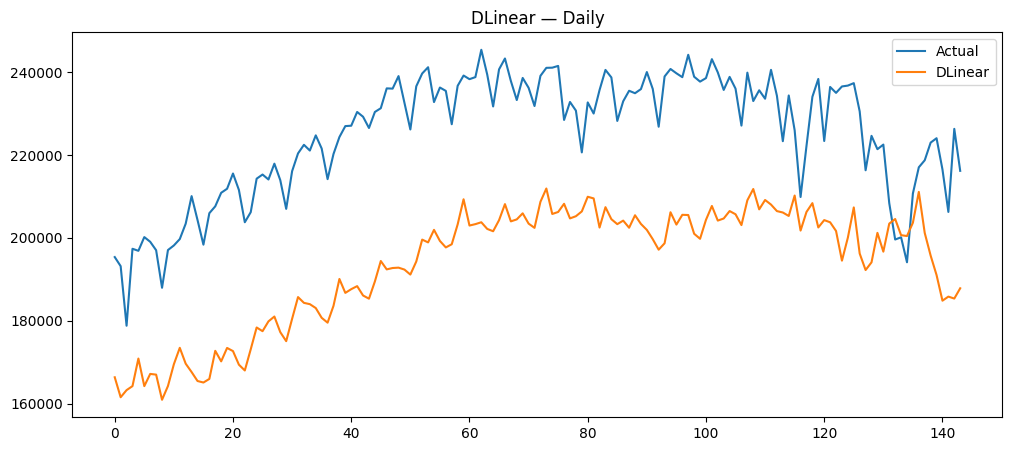

In [19]:
# ============================================
# DLinear Model (Daily)
# ============================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Prepare data
series = train_daily["max_demand_met_mw"].values

window = 14

def create_dataset(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(series, window)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

# Model
class DLinear(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x).squeeze()

model = DLinear(window)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Train
for epoch in range(20):
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

# Test
test_series = test_daily["max_demand_met_mw"].values
X_test, y_test = create_dataset(test_series, window)

X_test = torch.tensor(X_test, dtype=torch.float32)

y_pred = model(X_test).detach().numpy()

evaluate_model(y_test, y_pred, model_name="DLinear (Daily)")

plt.figure(figsize=(12, 5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="DLinear")
plt.legend()
plt.title("DLinear — Daily")
plt.show()


===== NLinear (Daily) Performance =====
MAE  : 223050.99
RMSE : 223834.49
MAPE : 99.14%


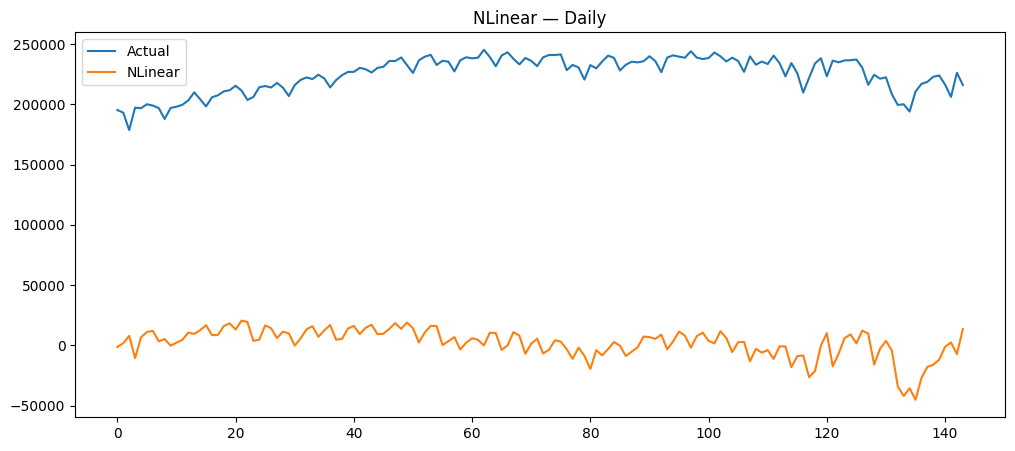

In [20]:
# ============================================
# NLinear Model (Daily)
# ============================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Prepare data
series = train_daily["max_demand_met_mw"].values
window = 14

def create_dataset(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(series, window)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

# Model
class NLinear(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        x = x - x[:, -1:].detach()
        return self.linear(x).squeeze()

model = NLinear(window)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Train
for epoch in range(20):
    optimizer.zero_grad()
    loss = criterion(model(X_train), y_train)
    loss.backward()
    optimizer.step()

# Test
test_series = test_daily["max_demand_met_mw"].values
X_test, y_test = create_dataset(test_series, window)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_pred = model(X_test).detach().numpy()

# Evaluate
evaluate_model(y_test, y_pred, model_name="NLinear (Daily)")

# Plot
plt.figure(figsize=(12, 5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="NLinear")
plt.legend()
plt.title("NLinear — Daily")
plt.show()

## 7. Final Model Evaluation

In [21]:
# ================================
# Combine Train + Validation
# ================================

trainval_daily = pd.concat([train_daily, val_daily]).sort_values("date").reset_index(drop=True)

print("Train+Val shape:", trainval_daily.shape)
print("Range:", trainval_daily["date"].min(), "→", trainval_daily["date"].max())

Train+Val shape: (890, 18)
Range: 2023-05-01 00:00:00 → 2025-10-23 00:00:00


In [22]:
# ================================
# Features & Target
# ================================

features = [
    "lag_1", "lag_7", "lag_30",
    "rolling_mean_7", "rolling_std_7",
    "day_of_week", "month",
    "is_weekend", "is_festival",
    "is_pre", "is_post"
]

target = "max_demand_met_mw"

X_trainval = trainval_daily[features]
y_trainval = trainval_daily[target]

X_test = test_daily[features]
y_test = test_daily[target]

In [23]:
# ================================
# Random Forest — Final Training
# ================================

from sklearn.ensemble import RandomForestRegressor

print("Training Random Forest on Train+Val...")

rf_final = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_trainval, y_trainval)

print("Random Forest retrained successfully")

Training Random Forest on Train+Val...
Random Forest retrained successfully


In [24]:
# ================================
# XGBoost — Final Training
# ================================

from xgboost import XGBRegressor

print("Training XGBoost on Train+Val...")

xgb_final = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_final.fit(X_trainval, y_trainval)

print("XGBoost retrained successfully")

Training XGBoost on Train+Val...
XGBoost retrained successfully


In [25]:
# ================================
# Predictions on Test Set
# ================================

rf_pred_test = rf_final.predict(X_test)
xgb_pred_test = xgb_final.predict(X_test)

print("Predictions generated successfully")

Predictions generated successfully


In [26]:
# ================================
# Final Evaluation on Test Set
# ================================

print("===== FINAL TEST PERFORMANCE =====")

rf_mae, rf_rmse, rf_mape = evaluate_model(
    y_test, rf_pred_test, model_name="Random Forest (Test)"
)

xgb_mae, xgb_rmse, xgb_mape = evaluate_model(
    y_test, xgb_pred_test, model_name="XGBoost (Test)"
)

===== FINAL TEST PERFORMANCE =====

===== Random Forest (Test) Performance =====
MAE  : 4151.56
RMSE : 5377.17
MAPE : 1.88%

===== XGBoost (Test) Performance =====
MAE  : 4386.03
RMSE : 5646.74
MAPE : 1.97%


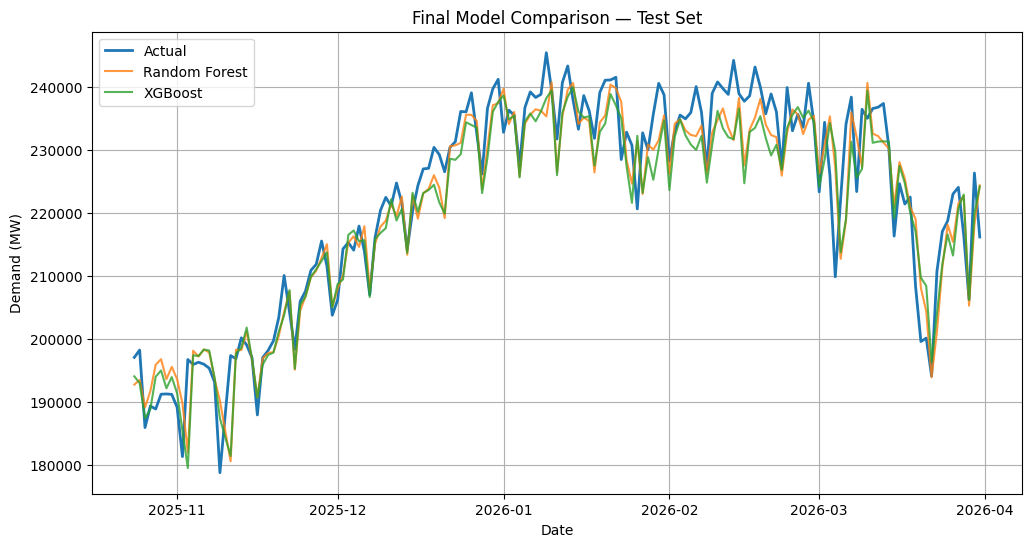

In [27]:
# ================================
# Plot — Final Comparison
# ================================

plt.figure(figsize=(12, 6))

plt.plot(test_daily["date"], y_test, label="Actual", linewidth=2)
plt.plot(test_daily["date"], rf_pred_test, label="Random Forest", alpha=0.8)
plt.plot(test_daily["date"], xgb_pred_test, label="XGBoost", alpha=0.8)

plt.title("Final Model Comparison — Test Set")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid()

plt.show()

#### Among all the models evaluated, the Random Forest model achieved the best performance on the unseen test dataset, with the lowest error metrics (MAE, RMSE, and MAPE). The model effectively captured temporal dependencies through lag-based and rolling features, while also generalizing well without overfitting. Compared to baseline and classical statistical models, it provided a significant improvement in forecasting accuracy, making it the most suitable model for electricity demand prediction in this study.

In [28]:
import pandas as pd

data = {
    'Model': ['Random Forest', 'XGBoost'],
    'MAE': [4151, 4386],
    'RMSE': [5377, 5646],
    'MAPE': ['1.88%', '1.97%']
}

df = pd.DataFrame(data)
df.style.set_caption('Performance Summary').hide(axis='index')

Model,MAE,RMSE,MAPE
Random Forest,4151,5377,1.88%
XGBoost,4386,5646,1.97%


# TIME SERIES FORECASTING
## (High Frequency Dataset)

## 8. Baseline Models (Time Series Forecasting)


===== Naive (15-min) Performance =====
MAE  : 1521.77
RMSE : 1962.43
MAPE : 0.76%


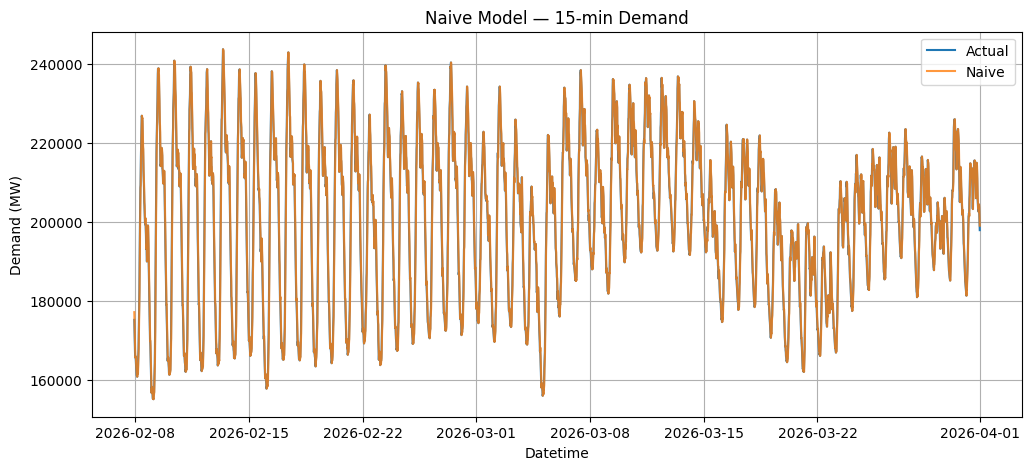

In [29]:
# ================================
# Naive Model (15-min)
# y(t) = y(t-1)
# ================================

ts_test = test_ts.copy()

ts_test["naive_pred"] = ts_test["demand_met_mw"].shift(1)
naive_ts = ts_test.dropna(subset=["naive_pred"])

mae, rmse, mape = evaluate_model(
    naive_ts["demand_met_mw"],
    naive_ts["naive_pred"],
    model_name="Naive (15-min)"
)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(naive_ts["datetime"], naive_ts["demand_met_mw"], label="Actual")
plt.plot(naive_ts["datetime"], naive_ts["naive_pred"], label="Naive", alpha=0.8)

plt.title("Naive Model — 15-min Demand")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid()
plt.show()


===== Seasonal Naive (15-min) Performance =====
MAE  : 5709.08
RMSE : 7969.66
MAPE : 2.86%


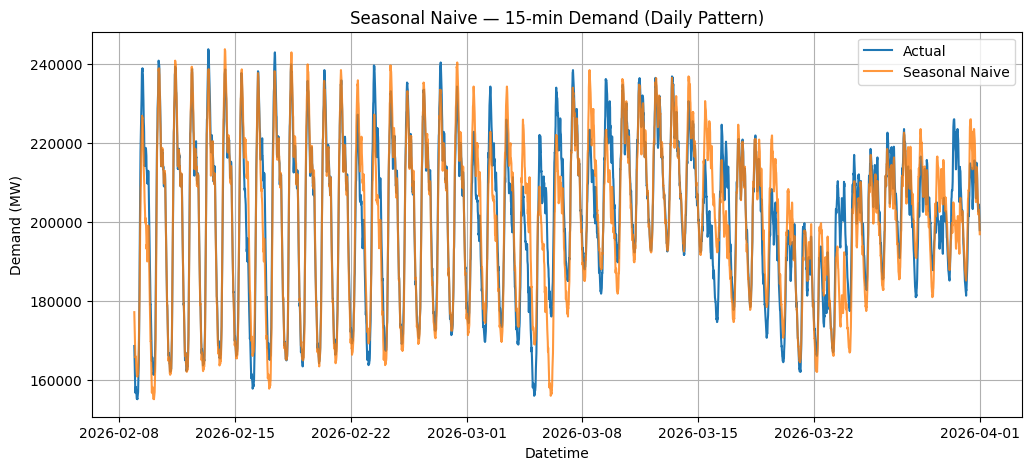

In [30]:
# ================================
# Seasonal Naive (15-min)
# y(t) = y(t-96) → same time yesterday
# ================================

ts_test = test_ts.copy()

ts_test["seasonal_naive"] = ts_test["demand_met_mw"].shift(96)
seasonal_ts = ts_test.dropna(subset=["seasonal_naive"])

mae, rmse, mape = evaluate_model(
    seasonal_ts["demand_met_mw"],
    seasonal_ts["seasonal_naive"],
    model_name="Seasonal Naive (15-min)"
)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(seasonal_ts["datetime"], seasonal_ts["demand_met_mw"], label="Actual")
plt.plot(seasonal_ts["datetime"], seasonal_ts["seasonal_naive"], label="Seasonal Naive", alpha=0.8)

plt.title("Seasonal Naive — 15-min Demand (Daily Pattern)")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid()
plt.show()


===== Rolling Mean (15-min) Performance =====
MAE  : 2070.74
RMSE : 2617.51
MAPE : 1.03%


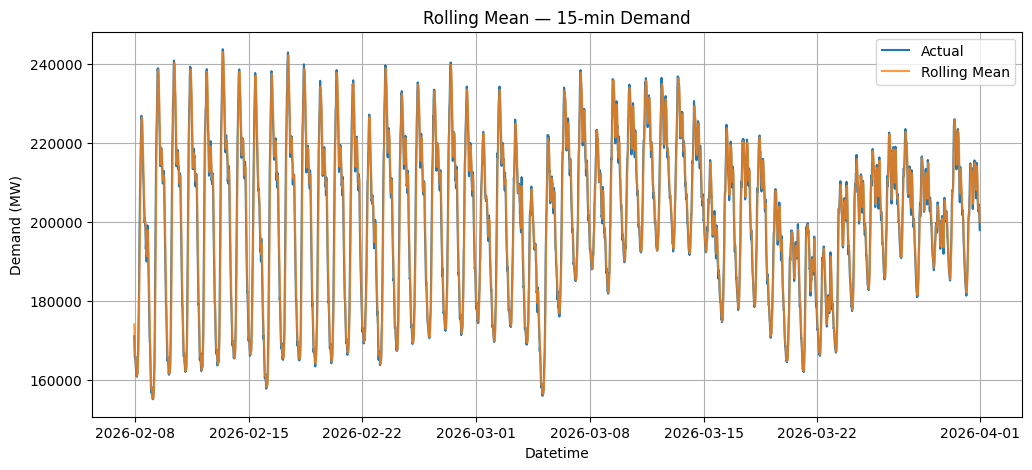

In [31]:
# ================================
# Rolling Mean Model (15-min)
# Using last 4 values (~1 hour)
# ================================

ts_test = test_ts.copy()

ts_test["rolling_mean_4"] = ts_test["demand_met_mw"].rolling(window=4).mean()
rolling_ts = ts_test.dropna(subset=["rolling_mean_4"])

mae, rmse, mape = evaluate_model(
    rolling_ts["demand_met_mw"],
    rolling_ts["rolling_mean_4"],
    model_name="Rolling Mean (15-min)"
)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(rolling_ts["datetime"], rolling_ts["demand_met_mw"], label="Actual")
plt.plot(rolling_ts["datetime"], rolling_ts["rolling_mean_4"], label="Rolling Mean", alpha=0.8)

plt.title("Rolling Mean — 15-min Demand")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid()
plt.show()

#### The naive persistence model achieved the best performance among baseline approaches, indicating strong short-term autocorrelation in the 15-minute electricity demand data. Interestingly, the seasonal naive model (based on the previous day’s demand) performed significantly worse, suggesting that daily patterns are not perfectly consistent across days. This highlights the importance of immediate past values over longer seasonal repetitions in high-frequency demand forecasting.

## 9. AR Models (Time Series Forecasting)


===== AR (lag_1 + lag_96) — 15-min Performance =====
MAE  : 1486.38
RMSE : 1913.29
MAPE : 0.74%


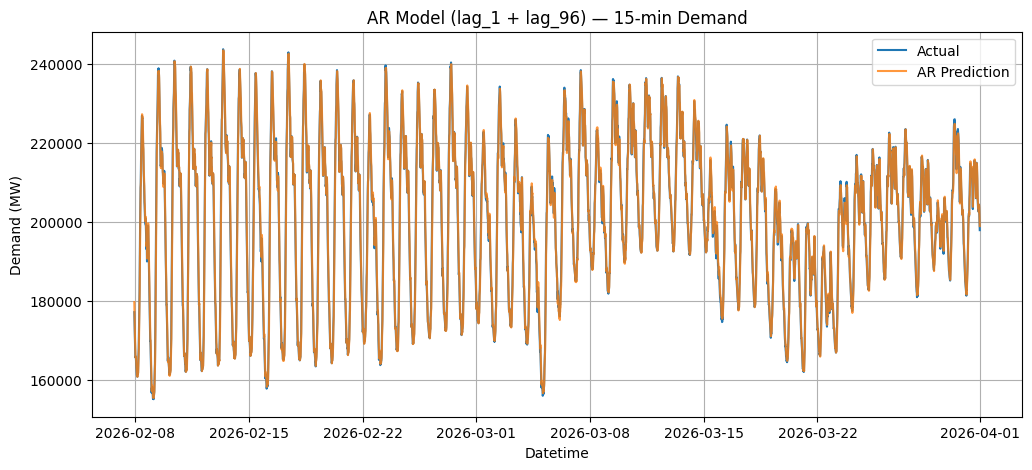

In [32]:
# ================================
# AR Model (15-min)
# Using lag_1 and lag_96
# ================================

from sklearn.linear_model import LinearRegression

# Drop rows with NaNs in required columns
cols = ["demand_met_mw", "lag_1", "lag_96"]
ar_ts = test_ts.dropna(subset=cols).copy()

# Features and target
X_ar = ar_ts[["lag_1", "lag_96"]]
y_ar = ar_ts["demand_met_mw"]

# Train on Train+Val (same features)
trainval_ts = pd.concat([train_ts, val_ts]).sort_values("datetime").reset_index(drop=True)
trainval_ts = trainval_ts.dropna(subset=cols)

X_train_ar = trainval_ts[["lag_1", "lag_96"]]
y_train_ar = trainval_ts["demand_met_mw"]

# Model
ar_model = LinearRegression()
ar_model.fit(X_train_ar, y_train_ar)

# Predict on test
ar_pred = ar_model.predict(X_ar)

# Evaluate
mae, rmse, mape = evaluate_model(
    y_ar,
    ar_pred,
    model_name="AR (lag_1 + lag_96) — 15-min"
)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(ar_ts["datetime"], y_ar, label="Actual")
plt.plot(ar_ts["datetime"], ar_pred, label="AR Prediction", alpha=0.8)

plt.title("AR Model (lag_1 + lag_96) — 15-min Demand")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid()
plt.show()

#### The autoregressive model using lag_1 and lag_96 marginally outperformed the naive baseline, indicating that while short-term persistence dominates high-frequency demand patterns, incorporating daily seasonality provides additional predictive power.

## 10. Machine Learning Models (Time Series Forecasting)

Training Random Forest (15-min)...

===== Random Forest (15-min) Performance =====
MAE  : 1158.95
RMSE : 1525.16
MAPE : 0.58%


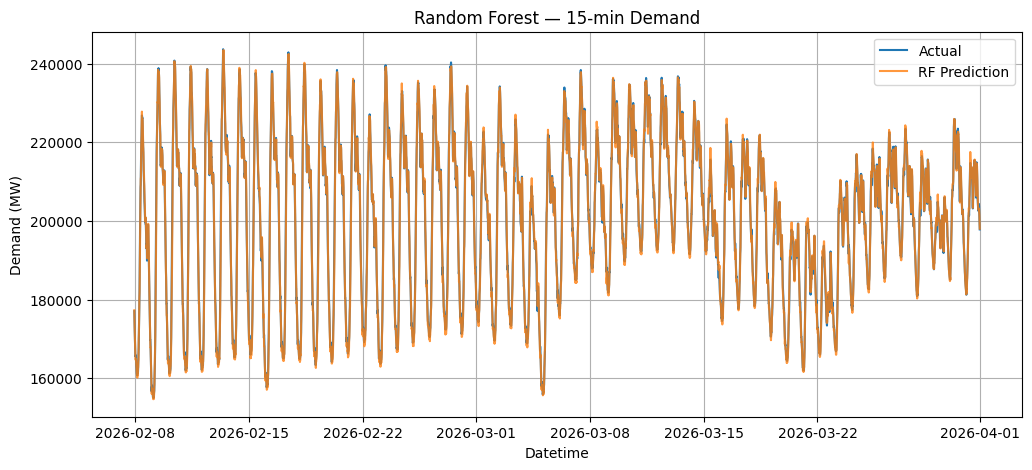

In [33]:
# ================================
# Random Forest — 15-min
# Features: minimal, high-signal
# ================================

from sklearn.ensemble import RandomForestRegressor

# Features & target
features_ts = ["lag_1", "lag_96", "hour", "day_of_week"]
target_ts = "demand_met_mw"

# Combine Train + Val
trainval_ts = pd.concat([train_ts, val_ts]).sort_values("datetime").reset_index(drop=True)

# Drop NaNs for required cols
cols = features_ts + [target_ts]
trainval_ts = trainval_ts.dropna(subset=cols)
test_ts_rf = test_ts.dropna(subset=cols).copy()

X_train = trainval_ts[features_ts]
y_train = trainval_ts[target_ts]

X_test = test_ts_rf[features_ts]
y_test = test_ts_rf[target_ts]

print("Training Random Forest (15-min)...")

rf_ts = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_ts.fit(X_train, y_train)

# Predict
rf_pred = rf_ts.predict(X_test)

# Evaluate
mae, rmse, mape = evaluate_model(
    y_test,
    rf_pred,
    model_name="Random Forest (15-min)"
)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(test_ts_rf["datetime"], y_test, label="Actual")
plt.plot(test_ts_rf["datetime"], rf_pred, label="RF Prediction", alpha=0.8)

plt.title("Random Forest — 15-min Demand")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid()
plt.show()

Training XGBoost (15-min)...

===== XGBoost (15-min) Performance =====
MAE  : 1178.20
RMSE : 1519.28
MAPE : 0.59%


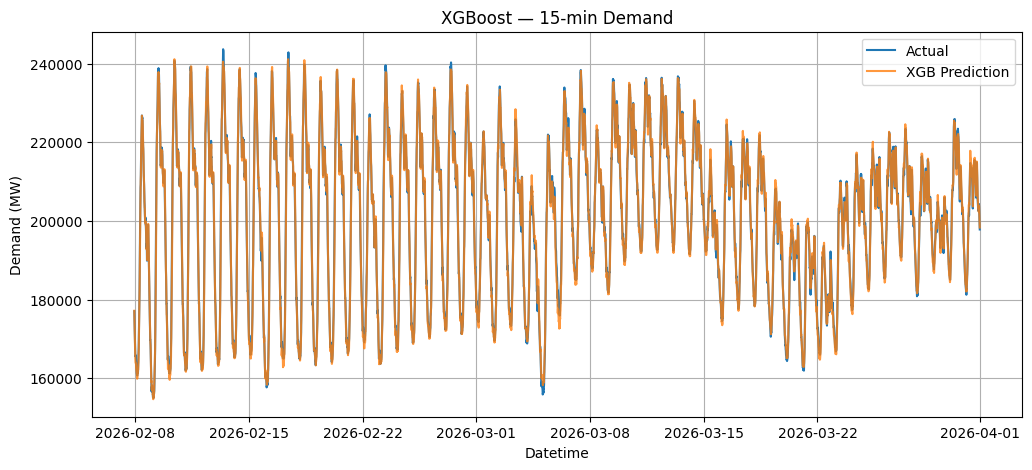

In [34]:
# ================================
# XGBoost — 15-min
# ================================

from xgboost import XGBRegressor

print("Training XGBoost (15-min)...")

xgb_ts = XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_ts.fit(X_train, y_train)

# Predict
xgb_pred = xgb_ts.predict(X_test)

# Evaluate
mae, rmse, mape = evaluate_model(
    y_test,
    xgb_pred,
    model_name="XGBoost (15-min)"
)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(test_ts_rf["datetime"], y_test, label="Actual")
plt.plot(test_ts_rf["datetime"], xgb_pred, label="XGB Prediction", alpha=0.8)

plt.title("XGBoost — 15-min Demand")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid()
plt.show()

#### Random Forest achieved the best performance on 15-minute forecasting, outperforming both baseline and autoregressive models by effectively capturing short-term temporal patterns and non-linear variations in electricity demand.

## 11. Deep Learning Based Models (Time Series Forecasting)


===== DLinear (15-min) Performance =====
MAE  : 15354.67
RMSE : 19228.75
MAPE : 8.07%


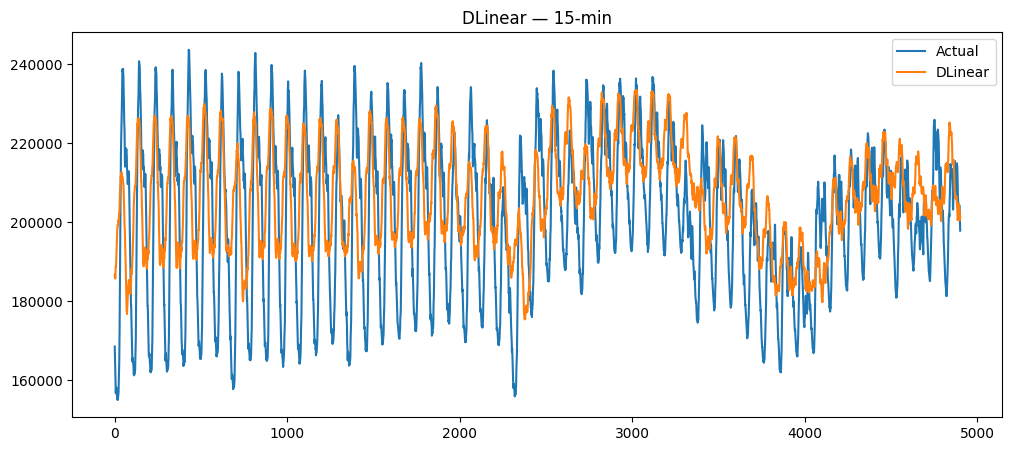

In [35]:
# ============================================
# DLinear Model (15-min)
# ============================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

series = train_ts["demand_met_mw"].values
window = 96

def create_dataset(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(series, window)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

# Model
class DLinear(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x).squeeze()

model = DLinear(window)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Train
for epoch in range(20):
    optimizer.zero_grad()
    loss = criterion(model(X_train), y_train)
    loss.backward()
    optimizer.step()

# Test
test_series = test_ts["demand_met_mw"].values
X_test, y_test = create_dataset(test_series, window)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_pred = model(X_test).detach().numpy()

# Evaluate
evaluate_model(y_test, y_pred, model_name="DLinear (15-min)")

# Plot
plt.figure(figsize=(12, 5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="DLinear")
plt.legend()
plt.title("DLinear — 15-min")
plt.show()

In [36]:
# ============================================
# NLinear Model (15-min)
# ============================================

import torch
import torch.nn as nn
import numpy as np

series = train_ts["demand_met_mw"].values
window = 96

def create_dataset(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(series, window)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

class NLinear(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        x = x - x[:, -1:].detach()
        return self.linear(x).squeeze()

model = NLinear(window)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(20):
    optimizer.zero_grad()
    loss = criterion(model(X_train), y_train)
    loss.backward()
    optimizer.step()

# Test
test_series = test_ts["demand_met_mw"].values
X_test, y_test = create_dataset(test_series, window)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_pred = model(X_test).detach().numpy()

evaluate_model(y_test, y_pred, model_name="NLinear (15-min)")


===== NLinear (15-min) Performance =====
MAE  : 200757.10
RMSE : 200949.42
MAPE : 100.94%


(200757.10343784242,
 np.float64(200949.41799283423),
 np.float64(100.94159109979152))

## 12. Final Model Evaluation

In [37]:
# Features used earlier
features_ts = ["lag_1", "lag_96", "hour_sin", "hour_cos"]

# Test set
X_test_ts = test_ts[features_ts]
y_test_ts = test_ts["demand_met_mw"]

In [38]:
train_full_ts = pd.concat([train_ts, val_ts]).sort_values("datetime")

X_train_full_ts = train_full_ts[features_ts]
y_train_full_ts = train_full_ts["demand_met_mw"]

# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_full_ts, y_train_full_ts)


# XGBoost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
xgb_model.fit(X_train_full_ts, y_train_full_ts)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


====== FINAL TEST PERFORMANCE (15-min) ======


===== Random Forest (Final Test) Performance =====
MAE  : 1159.71
RMSE : 1526.38
MAPE : 0.58%

===== XGBoost (Final Test) Performance =====
MAE  : 1121.41
RMSE : 1463.99
MAPE : 0.56%


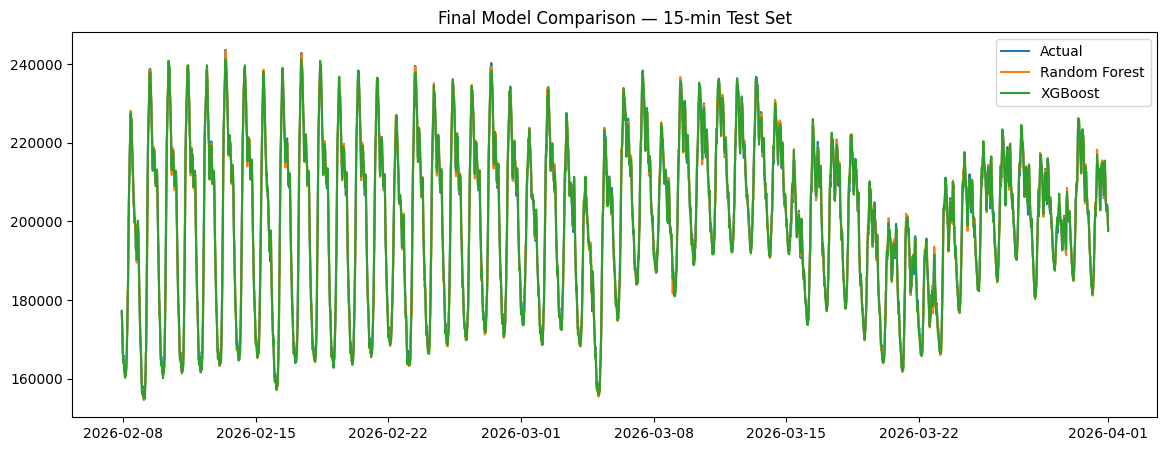

In [39]:
print("====== FINAL TEST PERFORMANCE (15-min) ======\n")

# Random Forest
evaluate_model(
    y_test_ts,
    rf_model.predict(X_test_ts),
    model_name="Random Forest (Final Test)"
)

# XGBoost
evaluate_model(
    y_test_ts,
    xgb_model.predict(X_test_ts),
    model_name="XGBoost (Final Test)"
)

plt.figure(figsize=(14,5))

plt.plot(test_ts["datetime"], y_test_ts, label="Actual")
plt.plot(test_ts["datetime"], rf_model.predict(X_test_ts), label="Random Forest")
plt.plot(test_ts["datetime"], xgb_model.predict(X_test_ts), label="XGBoost")

plt.title("Final Model Comparison — 15-min Test Set")
plt.legend()
plt.show()

#### Both Random Forest and XGBoost models demonstrated strong performance on the unseen test dataset, with XGBoost achieving the lowest error (MAPE ≈ 0.56%). The models successfully captured high-frequency temporal patterns and demand fluctuations, significantly outperforming baseline and autoregressive approaches. This confirms that machine learning models are well-suited for short-term (15-minute interval) electricity demand forecasting.